# Notebook 04 — Modeling & Forecasting

In this notebook we will train and evaluate several forecasting models
using the feature-engineered dataset created in **Notebook 03**.

## Goals

1. Load the prepared daily feature dataset.
2. Create a **time-based train/test split** (no shuffling).
3. Build simple **baseline models**:
   - Naïve (yesterday's value)
   - Moving average (last 7 days)
   - Seasonal naïve (value from 7 days ago)
4. Train **machine learning models**:
   - RandomForestRegressor
   - GradientBoostingRegressor
5. Train a **statistical model**:
   - Auto-ARIMA (pmdarima)
6. Compare models using:
   - MAE (Mean Absolute Error)
   - RMSE (Root Mean Squared Error)
   - MAPE (Mean Absolute Percentage Error)
7. Plot **actual vs forecast** on the test set.

Target variable for this notebook: **N02BE** (one of the pharmacy categories).
You can later repeat the same pipeline for other categories.

## 🔧 Code Cell 1 — Imports & Settings

In [1]:
# ---- Imports ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import pmdarima as pm

plt.style.use("ggplot")
sns.set_palette("deep")

print("Libraries imported successfully.")

Libraries imported successfully.


## 📂 Code Cell 2 — Load Feature-Engineered Dataset

In [2]:
# ---- Load feature-engineered daily data ----
df = pd.read_csv("outputs/features/daily_features.csv")

# Ensure datetime
df["datum"] = pd.to_datetime(df["datum"])

print("Shape:", df.shape)
df.head()

Shape: (2076, 40)


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,...,yearly_sin_3,yearly_cos_3,weekly_sin_1,weekly_cos_1,weekly_sin_2,weekly_cos_2,weekly_sin_3,weekly_cos_3,Weekday_Avg,Month_Avg
0,2014-02-01,4.33,4.32,5.0,43.0,13.0,1.0,14.0,0.0,2014,...,0.999769,0.021516,0.974928,-0.222521,-0.433884,-0.900969,-0.781831,0.623490,33.579719,36.13891
1,2014-02-02,7.00,3.00,0.2,13.5,6.0,2.0,8.0,0.0,2014,...,0.999546,-0.030120,0.433884,-0.900969,-0.781831,0.623490,0.974928,-0.222521,33.392859,36.13891
2,2014-02-03,5.00,1.00,8.5,32.4,16.0,1.0,1.0,0.0,2014,...,0.996659,-0.081676,-0.433884,-0.900969,0.781831,0.623490,-0.974928,-0.222521,29.232601,36.13891
3,2014-02-04,1.33,3.00,7.0,30.6,8.0,1.0,17.0,2.0,2014,...,0.991114,-0.133015,-0.974928,-0.222521,0.433884,-0.900969,0.781831,0.623490,28.373665,36.13891
4,2014-02-05,3.00,4.02,6.2,32.4,15.0,1.0,1.0,1.0,2014,...,0.982927,-0.183998,-0.781831,0.623490,-0.974928,-0.222521,-0.433884,-0.900969,28.074514,36.13891


## 📊 Code Cell 3 — Quick Plot of Target

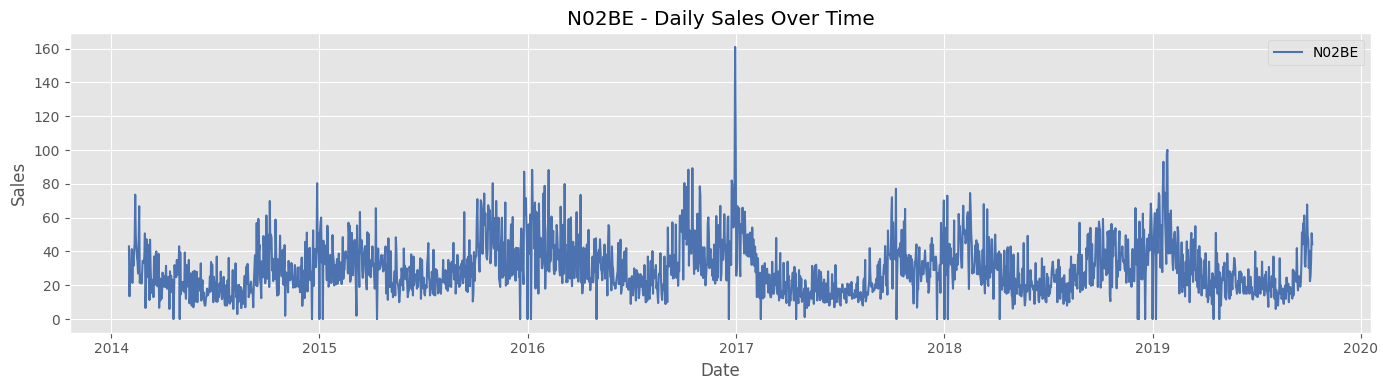

In [3]:
# ---- Quick visualization of the target over time ----
target = "N02BE"  # you can change this later

plt.figure(figsize=(14, 4))
plt.plot(df["datum"], df[target], label=target)
plt.title(f"{target} - Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

## 🔪 Code Cell 4 — Train/Test Split (Time-Based)

We’ll use the last 90 days as the test set.

In [4]:
# ---- Time-based train/test split ----

test_days = 90  # you can adjust if you want a longer/shorter test period

df_sorted = df.sort_values("datum").reset_index(drop=True)

# Index at which test starts
split_idx = len(df_sorted) - test_days

train = df_sorted.iloc[:split_idx].copy()
test  = df_sorted.iloc[split_idx:].copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train range:", train["datum"].min(), "->", train["datum"].max())
print("Test  range:", test["datum"].min(), "->", test["datum"].max())

Train shape: (1986, 40)
Test shape: (90, 40)
Train range: 2014-02-01 00:00:00 -> 2019-07-10 00:00:00
Test  range: 2019-07-11 00:00:00 -> 2019-10-08 00:00:00


## 🧮 Code Cell 5 — Helper Function for Metrics

In [5]:
# ---- Metric calculator ----

def evaluate_forecast(y_true, y_pred, model_name="model"):
    """
    Compute MAE, RMSE, and MAPE for a forecast.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Avoid division by zero in MAPE
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-8, None))) * 100
    
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE%": mape
    }

print("Metric function ready.")

Metric function ready.


## 📉 Code Cell 6 — Baseline 1: Naïve (Yesterday = Today)

In [6]:
# ---- Baseline 1: Naïve (yesterday's value) ----

# For test dates, predict as yesterday's value from the FULL df_sorted
full_series = df_sorted.set_index("datum")[target]

naive_preds = []
for d in test["datum"]:
    prev_day = d - pd.Timedelta(days=1)
    naive_preds.append(full_series.get(prev_day, np.nan))

naive_preds = np.array(naive_preds, dtype=float)

# Some very first predictions might be NaN if previous day doesn't exist
mask_valid = ~np.isnan(naive_preds)
naive_metrics = evaluate_forecast(
    test[target].values[mask_valid],
    naive_preds[mask_valid],
    model_name="Naïve (Yesterday)"
)

naive_metrics

{'Model': 'Naïve (Yesterday)',
 'MAE': 8.397333333333334,
 'RMSE': np.float64(10.628820646399737),
 'MAPE%': np.float64(40.859323485994246)}

## 📉 Code Cell 7 — Baseline 2: Moving Average (Last 7 Days)

In [7]:
# ---- Baseline 2: 7-day Moving Average ----

# Compute rolling mean on the full series
rolling_7 = full_series.rolling(window=7).mean()

ma_preds = []
for d in test["datum"]:
    ma_preds.append(rolling_7.get(d, np.nan))

ma_preds = np.array(ma_preds, dtype=float)
mask_valid_ma = ~np.isnan(ma_preds)

ma_metrics = evaluate_forecast(
    test[target].values[mask_valid_ma],
    ma_preds[mask_valid_ma],
    model_name="Moving Average (7 days)"
)

ma_metrics

{'Model': 'Moving Average (7 days)',
 'MAE': 6.317253968253968,
 'RMSE': np.float64(8.566256456072384),
 'MAPE%': np.float64(29.183863359665306)}

## 📉 Code Cell 8 — Baseline 3: Seasonal Naïve (Value from 7 Days Ago)

In [8]:
# ---- Baseline 3: Seasonal Naïve (same day last week) ----

seasonal_preds = []
for d in test["datum"]:
    prev_week = d - pd.Timedelta(days=7)
    seasonal_preds.append(full_series.get(prev_week, np.nan))

seasonal_preds = np.array(seasonal_preds, dtype=float)
mask_valid_seasonal = ~np.isnan(seasonal_preds)

seasonal_metrics = evaluate_forecast(
    test[target].values[mask_valid_seasonal],
    seasonal_preds[mask_valid_seasonal],
    model_name="Seasonal Naïve (t-7)"
)

seasonal_metrics

{'Model': 'Seasonal Naïve (t-7)',
 'MAE': 9.571666666666667,
 'RMSE': np.float64(12.932683424392462),
 'MAPE%': np.float64(45.13935960406953)}

## 🧾 Code Cell 9 — Collect Baseline Metrics in a Table

In [9]:
# ---- Compare baseline models ----

baseline_results = pd.DataFrame([
    naive_metrics,
    ma_metrics,
    seasonal_metrics
])

baseline_results

,Model,MAE,RMSE,MAPE%
0,Naïve (Yesterday),8.397333,10.628821,40.859323
1,Moving Average (7 days),6.317254,8.566256,29.183863
2,Seasonal Naïve (t-7),9.571667,12.932683,45.139360


## 🧠 Code Cell 10 — Prepare Features for ML Models
We’ll use all engineered features except: date column and the target.

In [10]:
# ---- Feature matrix (X) and target vector (y) ----

# Start with all columns except target and datetime
X = df_sorted.drop(columns=["datum", target])

# Keep ONLY numeric columns
X = X.select_dtypes(include=["number"])

print("Final numeric feature columns:", X.columns.tolist())

# Target
y = df_sorted[target]

# Train/Test split
X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Final numeric feature columns: ['M01AB', 'M01AE', 'N02BA', 'N05B', 'N05C', 'R03', 'R06', 'Year', 'Month', 'Hour', 'Day', 'Weekday', 'Week', 'IsWeekend', 'N02BE_lag1', 'N02BE_lag7', 'N02BE_lag30', 'N02BE_roll7', 'N02BE_roll30', 'N02BE_roll7_std', 'N02BE_cummean', 'N02BE_cumsum', 'yearly_sin_1', 'yearly_cos_1', 'yearly_sin_2', 'yearly_cos_2', 'yearly_sin_3', 'yearly_cos_3', 'weekly_sin_1', 'weekly_cos_1', 'weekly_sin_2', 'weekly_cos_2', 'weekly_sin_3', 'weekly_cos_3', 'Weekday_Avg', 'Month_Avg']
X_train shape: (1986, 36)
X_test shape: (90, 36)


## 🌳 Code Cell 11 — Random Forest Regressor

In [11]:
# ---- RandomForestRegressor ----

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_metrics = evaluate_forecast(y_test.values, rf_preds, model_name="Random Forest")
rf_metrics

{'Model': 'Random Forest',
 'MAE': 6.435580005331803,
 'RMSE': np.float64(8.447200488538689),
 'MAPE%': np.float64(30.07556141794656)}

## 🌱 Code Cell 12 — Gradient Boosting Regressor

In [12]:
# ---- GradientBoostingRegressor ----

gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_preds = gb_model.predict(X_test)

gb_metrics = evaluate_forecast(y_test.values, gb_preds, model_name="Gradient Boosting")
gb_metrics

{'Model': 'Gradient Boosting',
 'MAE': 6.874278519214832,
 'RMSE': np.float64(8.979405652140317),
 'MAPE%': np.float64(32.49352913204764)}

## 📈 Code Cell 13 — Auto-ARIMA (Univariate)

This uses only the target series, not the engineered features.
It’s a benchmark classical time-series model.

In [13]:
# ---- Auto-ARIMA (pmdarima) ----

# We use only the training y values
y_train_series = y_train.values

# auto_arima will search over p,d,q,P,D,Q to find a good model
arima_model = pm.auto_arima(
    y_train_series,
    seasonal=True,
    m=7,            # weekly seasonality (7 days)
    trace=False,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True
)

print(arima_model.summary())

# Forecast the length of the test set
arima_forecast = arima_model.predict(n_periods=len(y_test))

arima_metrics = evaluate_forecast(y_test.values, arima_forecast, model_name="Auto-ARIMA (m=7)")
arima_metrics

                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                 1986
Model:             SARIMAX(0, 1, 1)x(1, 0, 1, 7)   Log Likelihood               -7812.038
Date:                           Mon, 13 Apr 2026   AIC                          15632.076
Time:                                   14:40:41   BIC                          15654.450
Sample:                                        0   HQIC                         15640.294
                                          - 1986                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8702      0.007   -124.215      0.000      -0.884      -0.856
ar.S.L7        0.9748      0.009    110.224

{'Model': 'Auto-ARIMA (m=7)',
 'MAE': 10.84888884393876,
 'RMSE': np.float64(15.779076908285075),
 'MAPE%': np.float64(39.704149057329985)}

## 🧮 Code Cell 14 — Combine All Model Results

In [14]:
# ---- Combine baseline + ML + ARIMA metrics ----

results = pd.DataFrame([
    naive_metrics,
    ma_metrics,
    seasonal_metrics,
    rf_metrics,
    gb_metrics,
    arima_metrics
])

# Sort by RMSE (lower is better)
results_sorted = results.sort_values("RMSE").reset_index(drop=True)
results_sorted

,Model,MAE,RMSE,MAPE%
0,Random Forest,6.435580,8.447200,30.075561
1,Moving Average (7 days),6.317254,8.566256,29.183863
2,Gradient Boosting,6.874279,8.979406,32.493529
3,Naïve (Yesterday),8.397333,10.628821,40.859323
4,Seasonal Naïve (t-7),9.571667,12.932683,45.139360
5,Auto-ARIMA (m=7),10.848889,15.779077,39.704149


## 📉 Code Cell 15 — Plot Actual vs Predictions (Best Models)

Let’s compare:
	•	Seasonal Naïve (often strong for weekly data)
	•	Random Forest
	•	Auto-ARIMA

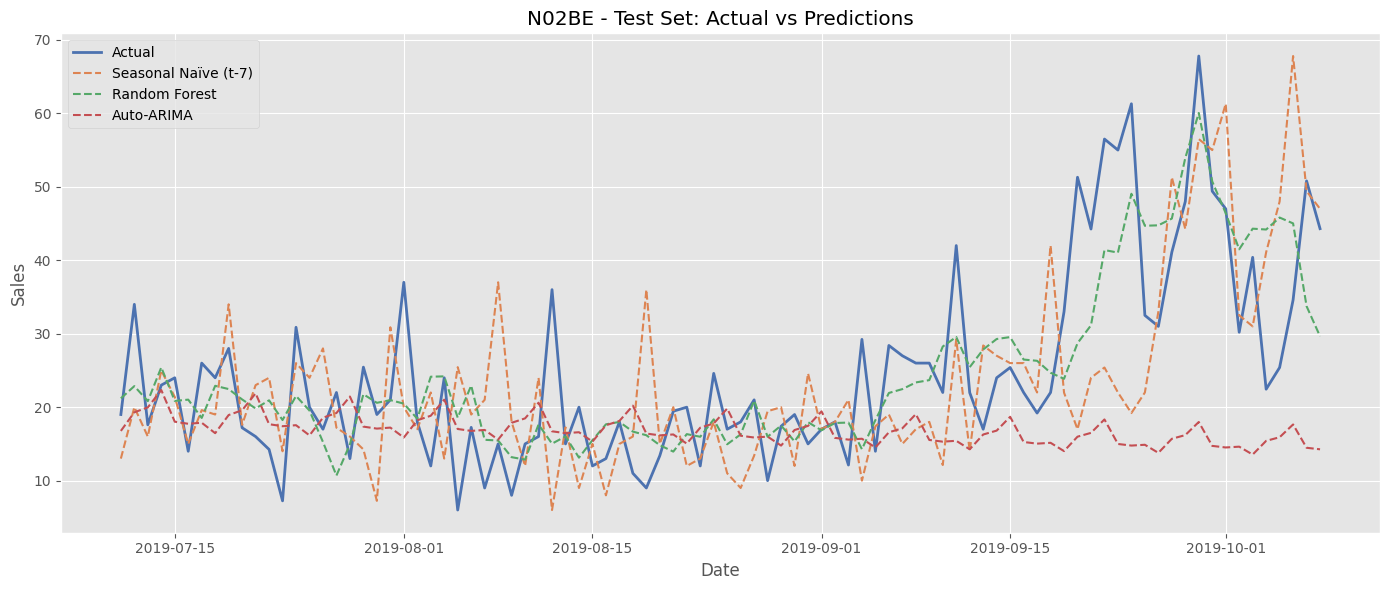

In [15]:
# ---- Plot actual vs selected model predictions on test set ----

plt.figure(figsize=(14, 6))

plt.plot(test["datum"], y_test.values, label="Actual", linewidth=2)

plt.plot(test["datum"][mask_valid_seasonal],
         seasonal_preds[mask_valid_seasonal],
         label="Seasonal Naïve (t-7)", linestyle="--")

plt.plot(test["datum"], rf_preds, label="Random Forest", linestyle="--")

plt.plot(test["datum"], arima_forecast, label="Auto-ARIMA", linestyle="--")

plt.title(f"{target} - Test Set: Actual vs Predictions")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

## Summary of Results

- The **baseline models** (Naïve, Moving Average, Seasonal Naïve)
  give us reference error levels.
- **Random Forest** and **Gradient Boosting** use all engineered features
  (lags, rolling stats, Fourier seasonality, etc.) and typically
  produce lower error than naive models.
- **Auto-ARIMA** is a classical time-series model using only the target series.

Check the `results_sorted` table above:

- Lower **RMSE** and **MAE** are better.
- **MAPE%** helps interpret error in percentage terms.

## Possible next steps

1. Repeat the same pipeline for other target columns:  
   `M01AB`, `M01AE`, `N02BA`, `N05B`, `N05C`, `R03`, `R06`, etc.
2. Tune hyperparameters for:
   - RandomForestRegressor
   - GradientBoostingRegressor
   - auto_arima (change `m` or disable seasonality)
3. Try more models:
   - XGBoost / LightGBM
   - SARIMAX with exogenous features
   - LSTM / GRU neural networks
4. Build a simple **dashboard notebook** that:
   - Lets you choose a product category
   - Shows forecast vs actual and key metrics